In [10]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

LOG_FILE = Path("backlog/baseline--gipfel-train-8b-250s-4n-1969685.log")

pattern = re.compile(
    r"\[(?P<timestamp>[\d\-: .]+)\]\s+"
    r"iteration\s+(?P<iteration>\d+)/\s*(?P<total_iterations>\d+)\s+\| "
    r"consumed samples:\s+(?P<consumed_samples>\d+)\s+\| "
    r"elapsed time per iteration \(ms\):\s+(?P<iter_time_ms>[\d.]+)\s+\| "
    r"throughput per GPU \(TFLOP/s/GPU\):\s+(?P<tflops_per_gpu>[\d.]+)\s+\| "
    r"tokens/sec/GPU:\s+(?P<tokens_sec_gpu>\d+)\s+\| "
    r"learning rate:\s+(?P<lr>[\d.Ee+-]+)\s+\| "
    r"global batch size:\s+(?P<global_batch_size>\d+)\s+\| "
    r"lm loss:\s+(?P<lm_loss>[\d.Ee+-]+)\s+\| "
    r"loss scale:\s+(?P<loss_scale>[\d.]+)\s+\| "
    r"grad norm:\s+(?P<grad_norm>[\d.Ee+-]+)\s+\| "
    r"number of skipped iterations:\s+(?P<skipped_iters>\d+)\s+\| "
    r"number of nan iterations:\s+(?P<nan_iters>\d+)"
)

rows = []

with LOG_FILE.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            rows.append(match.groupdict())

df = pd.DataFrame(rows)

# Convert dtypes
numeric_cols = [
    "iteration", "total_iterations", "consumed_samples",
    "iter_time_ms", "tflops_per_gpu", "tokens_sec_gpu",
    "lr", "global_batch_size", "lm_loss", "loss_scale",
    "grad_norm", "skipped_iters", "nan_iters"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["iter_time_s"] = df["iter_time_ms"] / 1000
df["total_tokens_per_iter"] = df["global_batch_size"] * 4096
df["tokens_sec_total"] = df["tokens_sec_gpu"] * 16  # 4 nodes × 4 GPUs
df["tflops_total"] = df["tflops_per_gpu"] * 16

df.head()

,timestamp,iteration,total_iterations,consumed_samples,iter_time_ms,tflops_per_gpu,tokens_sec_gpu,lr,global_batch_size,lm_loss,loss_scale,grad_norm,skipped_iters,nan_iters,iter_time_s,total_tokens_per_iter,tokens_sec_total,tflops_total
0,2026-04-28 08:18:45.753644,1,250,256,12066.5,251.6,5431,0.000015,256,11.62335,1.0,13.970,0,0,12.0665,1048576,86896,4025.6
1,2026-04-28 08:18:51.964206,2,250,512,9138.4,332.3,7172,0.000030,256,11.62525,1.0,11.586,0,0,9.1384,1048576,114752,5316.8
2,2026-04-28 08:18:58.143003,3,250,768,6178.7,491.5,10607,0.000045,256,11.14157,1.0,102.112,0,0,6.1787,1048576,169712,7864.0
3,2026-04-28 08:19:04.337193,4,250,1024,6194.0,490.2,10581,0.000060,256,12.75088,1.0,39.235,0,0,6.1940,1048576,169296,7843.2
4,2026-04-28 08:19:10.512065,5,250,1280,6174.7,491.8,10614,0.000075,256,15.17042,1.0,252.501,0,0,6.1747,1048576,169824,7868.8


In [5]:
# Basic run summary

summary = {
    "iterations_logged": len(df),
    "first_iteration": df["iteration"].min(),
    "last_iteration": df["iteration"].max(),
    "mean_iter_time_s": df["iter_time_s"].mean(),
    "median_iter_time_s": df["iter_time_s"].median(),
    "mean_tokens_sec_gpu": df["tokens_sec_gpu"].mean(),
    "mean_tokens_sec_total": df["tokens_sec_total"].mean(),
    "mean_tflops_gpu": df["tflops_per_gpu"].mean(),
    "mean_tflops_total": df["tflops_total"].mean(),
    "final_loss": df.iloc[-1]["lm_loss"],
    "min_loss": df["lm_loss"].min(),
    "max_grad_norm": df["grad_norm"].max(),
    "total_skipped_iterations": df["skipped_iters"].sum(),
    "total_nan_iterations": df["nan_iters"].sum(),
}

pd.Series(summary)

iterations_logged              250.000000
first_iteration                  1.000000
last_iteration                 250.000000
mean_iter_time_s                 6.289846
median_iter_time_s               6.206600
mean_tokens_sec_gpu          10512.580000
mean_tokens_sec_total       168201.280000
mean_tflops_gpu                487.081600
mean_tflops_total             7793.305600
final_loss                       4.759389
min_loss                         4.688889
max_grad_norm                  252.501000
total_skipped_iterations         0.000000
total_nan_iterations             0.000000
dtype: float64

In [6]:
# More stable performance summary after warmup

WARMUP_CUTOFF = 20

stable = df[df["iteration"] > WARMUP_CUTOFF]

stable_summary = {
    "stable_iterations": len(stable),
    "mean_iter_time_s": stable["iter_time_s"].mean(),
    "std_iter_time_s": stable["iter_time_s"].std(),
    "mean_tokens_sec_gpu": stable["tokens_sec_gpu"].mean(),
    "std_tokens_sec_gpu": stable["tokens_sec_gpu"].std(),
    "mean_tflops_gpu": stable["tflops_per_gpu"].mean(),
    "std_tflops_gpu": stable["tflops_per_gpu"].std(),
    "mean_loss": stable["lm_loss"].mean(),
    "final_loss": stable.iloc[-1]["lm_loss"],
    "mean_grad_norm": stable["grad_norm"].mean(),
}

pd.Series(stable_summary)

stable_iterations        230.000000
mean_iter_time_s           6.263680
std_iter_time_s            0.953811
mean_tokens_sec_gpu    10537.260870
std_tokens_sec_gpu       493.252030
mean_tflops_gpu          488.225217
std_tflops_gpu            22.858308
mean_loss                  5.949248
final_loss                 4.759389
mean_grad_norm             2.231296
dtype: float64

In [ ]:
# Last N iterations, steady state!

LAST_N = 50
tail = df.tail(LAST_N)

tail_summary = {
    f"last_{LAST_N}_mean_iter_time_s": tail["iter_time_s"].mean(),
    f"last_{LAST_N}_mean_tokens_sec_gpu": tail["tokens_sec_gpu"].mean(),
    f"last_{LAST_N}_mean_tokens_sec_total": tail["tokens_sec_total"].mean(),
    f"last_{LAST_N}_mean_tflops_gpu": tail["tflops_per_gpu"].mean(),
    f"last_{LAST_N}_mean_tflops_total": tail["tflops_total"].mean(),
    f"last_{LAST_N}_mean_loss": tail["lm_loss"].mean(),
    "final_loss": df.iloc[-1]["lm_loss"],
}

pd.Series(tail_summary)

last_50_mean_iter_time_s              6.222318
last_50_mean_tokens_sec_gpu       10532.800000
last_50_mean_tokens_sec_total    168524.800000
last_50_mean_tflops_gpu             488.018000
last_50_mean_tflops_total          7808.288000
last_50_mean_loss                     4.920656
final_loss                            4.759389
dtype: float64

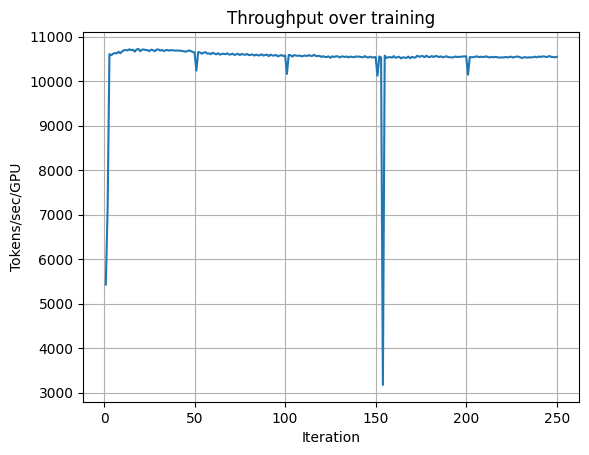

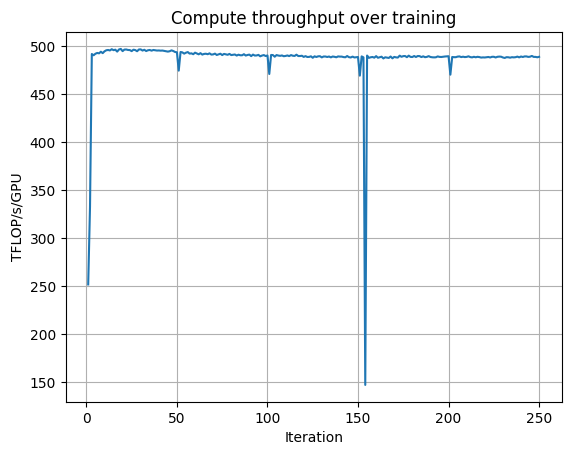

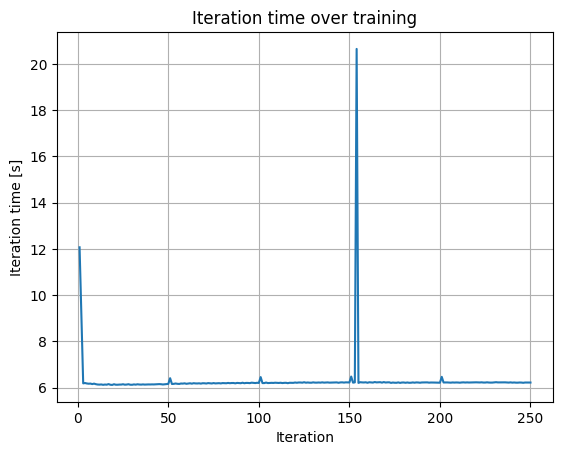

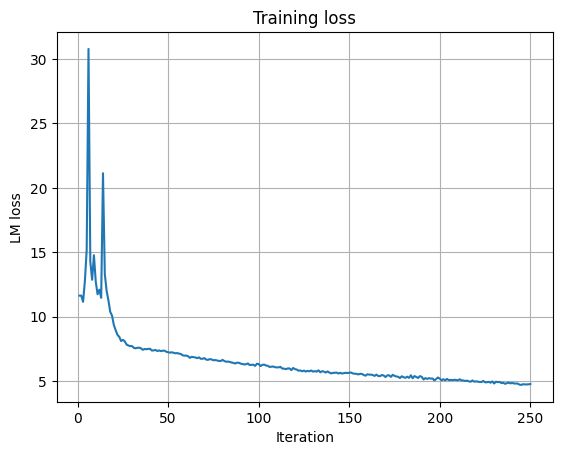

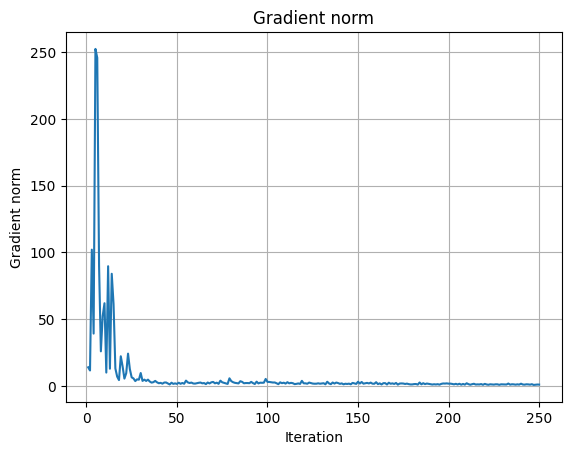

In [8]:
# Plots

plt.figure()
plt.plot(df["iteration"], df["tokens_sec_gpu"])
plt.xlabel("Iteration")
plt.ylabel("Tokens/sec/GPU")
plt.title("Throughput over training")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["iteration"], df["tflops_per_gpu"])
plt.xlabel("Iteration")
plt.ylabel("TFLOP/s/GPU")
plt.title("Compute throughput over training")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["iteration"], df["iter_time_s"])
plt.xlabel("Iteration")
plt.ylabel("Iteration time [s]")
plt.title("Iteration time over training")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["iteration"], df["lm_loss"])
plt.xlabel("Iteration")
plt.ylabel("LM loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["iteration"], df["grad_norm"])
plt.xlabel("Iteration")
plt.ylabel("Gradient norm")
plt.title("Gradient norm")
plt.grid(True)
plt.show()

## Steady State Analysis (Iterations 200-250)
         avg_tflops  std_tflops  cv_tflops (%)  avg_iter_s  max_loss_diff
run                                                                      
1976838  483.098039    2.619198       0.542167    6.285671       0.421950
1969685  488.041176    2.610684       0.534931    6.222022       0.483293
1975423  485.784314    2.633581       0.542130    6.250904       0.444910


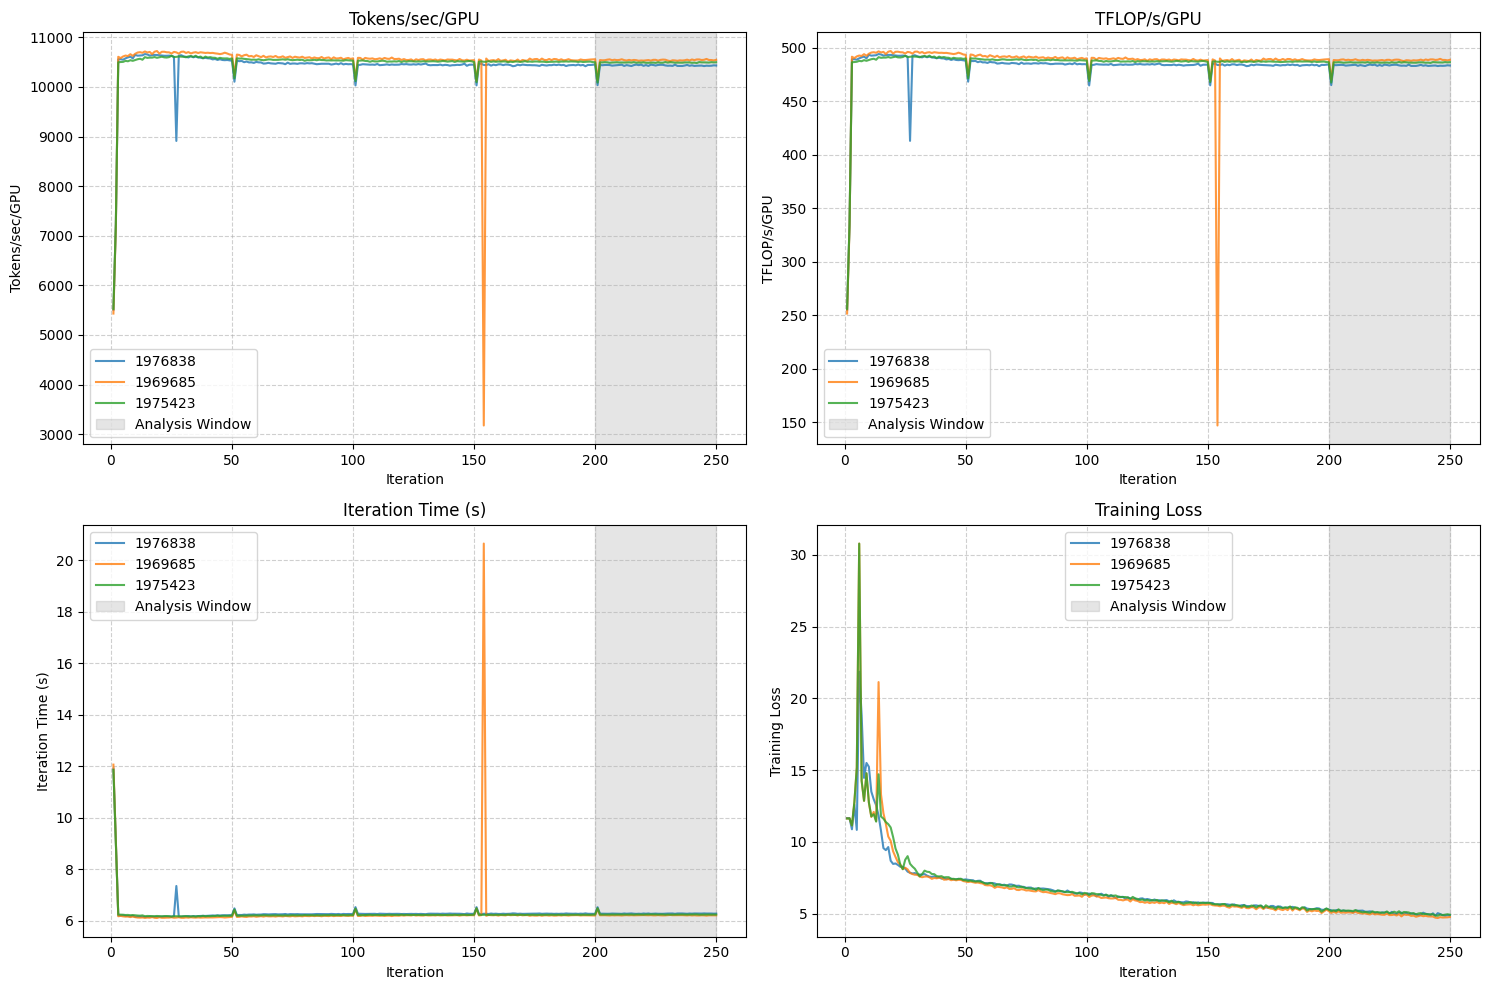

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
LOG_DIR = Path("backlog")
LOG_FILES = [
    "gipfel-train-8b-250s-4n-1976838.log",
    "gipfel-train-8b-250s-4n-1969685.log",
    "gipfel-train-8b-250s-4n-1975423.log"
]

# We are testing stability in this specific window
WINDOW_START = 200
WINDOW_END = 250

pattern = re.compile(
    r"\[(?P<timestamp>[\d\-: .]+)\]\s+"
    r"iteration\s+(?P<iteration>\d+)/\s*(?P<total_iterations>\d+)\s+\| "
    r"consumed samples:\s+(?P<consumed_samples>\d+)\s+\| "
    r"elapsed time per iteration \(ms\):\s+(?P<iter_time_ms>[\d.]+)\s+\| "
    r"throughput per GPU \(TFLOP/s/GPU\):\s+(?P<tflops_per_gpu>[\d.]+)\s+\| "
    r"tokens/sec/GPU:\s+(?P<tokens_sec_gpu>\d+)\s+\| "
    r"learning rate:\s+(?P<lr>[\d.Ee+-]+)\s+\| "
    r"global batch size:\s+(?P<global_batch_size>\d+)\s+\| "
    r"lm loss:\s+(?P<lm_loss>[\d.Ee+-]+)\s+\| "
    r"loss scale:\s+(?P<loss_scale>[\d.]+)\s+\| "
    r"grad norm:\s+(?P<grad_norm>[\d.Ee+-]+)\s+\| "
    r"number of skipped iterations:\s+(?P<skipped_iters>\d+)\s+\| "
    r"number of nan iterations:\s+(?P<nan_iters>\d+)"
)

def parse_log(file_path):
    rows = []
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                rows.append(match.groupdict())
    
    df = pd.DataFrame(rows)
    numeric_cols = [
        "iteration", "total_iterations", "consumed_samples",
        "iter_time_ms", "tflops_per_gpu", "tokens_sec_gpu",
        "lr", "global_batch_size", "lm_loss", "loss_scale",
        "grad_norm", "skipped_iters", "nan_iters"
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col])
    
    df["iter_time_s"] = df["iter_time_ms"] / 1000
    return df

# --- Process Data ---
all_runs = {}
for fname in LOG_FILES:
    label = fname.split('-')[-1].replace('.log', '') # Use Job ID as label
    if "baseline" in fname:
        label = f"baseline_{label}"
    all_runs[label] = parse_log(LOG_DIR / fname)

# --- Variance Analysis (Steps 200-250) ---
comparison_metrics = []
for label, df in all_runs.items():
    window = df[(df["iteration"] >= WINDOW_START) & (df["iteration"] <= WINDOW_END)]
    
    comparison_metrics.append({
        "run": label,
        "avg_tflops": window["tflops_per_gpu"].mean(),
        "std_tflops": window["tflops_per_gpu"].std(),
        "cv_tflops (%)": (window["tflops_per_gpu"].std() / window["tflops_per_gpu"].mean()) * 100,
        "avg_iter_s": window["iter_time_s"].mean(),
        "max_loss_diff": window["lm_loss"].max() - window["lm_loss"].min()
    })

comparison_df = pd.DataFrame(comparison_metrics).set_index("run")
print("## Steady State Analysis (Iterations 200-250)")
print(comparison_df)

# --- Overlay Plots ---
metrics_to_plot = [
    ("tokens_sec_gpu", "Tokens/sec/GPU"),
    ("tflops_per_gpu", "TFLOP/s/GPU"),
    ("iter_time_s", "Iteration Time (s)"),
    ("lm_loss", "Training Loss")
]

plt.figure(figsize=(15, 10))
for i, (col, title) in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 2, i)
    for label, df in all_runs.items():
        plt.plot(df["iteration"], df[col], label=label, alpha=0.8)
    
    plt.axvspan(WINDOW_START, WINDOW_END, color='gray', alpha=0.2, label='Analysis Window')
    plt.title(title)
    plt.xlabel("Iteration")
    plt.ylabel(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()